# Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Compreensão e padronização dos dados

In [17]:
from dotenv import load_dotenv
import os

load_dotenv()
path_training = os.getenv('TRAINING_DATA_PATH')

def get_file():
    return [f for f in os.listdir(path_training) if '.csv' in f.lower()][0]

csv_file = f'{path_training}/{get_file()}'

df = pd.read_csv(csv_file, delimiter=';')
df.head(5)


,date,price_br,price_us,temperature_2m_max,temperature_2m_min,wind_speed_10m_max,rain_sum,precipitation_hours,rain
0,2015-02-01,"268,04","99,57",1.789,-0.461000,16.746773,0.0,0.0,0.0
1,2015-05-01,"271,54","99,98",13.589,3.589000,16.923828,0.1,1.0,0.0
2,2015-06-01,"276,94","102,65",16.189,8.238999,17.238699,2.3,6.0,0.2
3,2015-07-01,"281,66","104,05",25.189,12.839000,12.979984,0.0,0.0,0.0
4,2015-08-01,"282,59","105,92",24.239,9.339000,11.966954,0.0,0.0,0.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2662 entries, 0 to 2661
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 2662 non-null   object 
 1   price_br             2662 non-null   object 
 2   price_us             2662 non-null   object 
 3   temperature_2m_max   2662 non-null   float64
 4   temperature_2m_min   2662 non-null   float64
 5   wind_speed_10m_max   2662 non-null   float64
 6   rain_sum             2662 non-null   float64
 7   precipitation_hours  2662 non-null   float64
 8   rain                 2662 non-null   float64
dtypes: float64(6), object(3)
memory usage: 187.3+ KB


In [19]:
df['price_br'] = df['price_br'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype('float64')
df['price_us'] = df['price_us'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype('float64')
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

print(f"Data types after conversion:\n{df.dtypes}")

Data types after conversion:
date                   datetime64[ns]
price_br                      float64
price_us                      float64
temperature_2m_max            float64
temperature_2m_min            float64
wind_speed_10m_max            float64
rain_sum                      float64
precipitation_hours           float64
rain                          float64
dtype: object


In [20]:
count_na = df.isna().sum()
count_null = df.isnull().sum()

print(f"Faltantes (NA):\n{count_na}\n\nNulos (NULL):\n{count_null}")

Faltantes (NA):
date                   0
price_br               0
price_us               0
temperature_2m_max     0
temperature_2m_min     0
wind_speed_10m_max     0
rain_sum               0
precipitation_hours    0
rain                   0
dtype: int64

Nulos (NULL):
date                   0
price_br               0
price_us               0
temperature_2m_max     0
temperature_2m_min     0
wind_speed_10m_max     0
rain_sum               0
precipitation_hours    0
rain                   0
dtype: int64


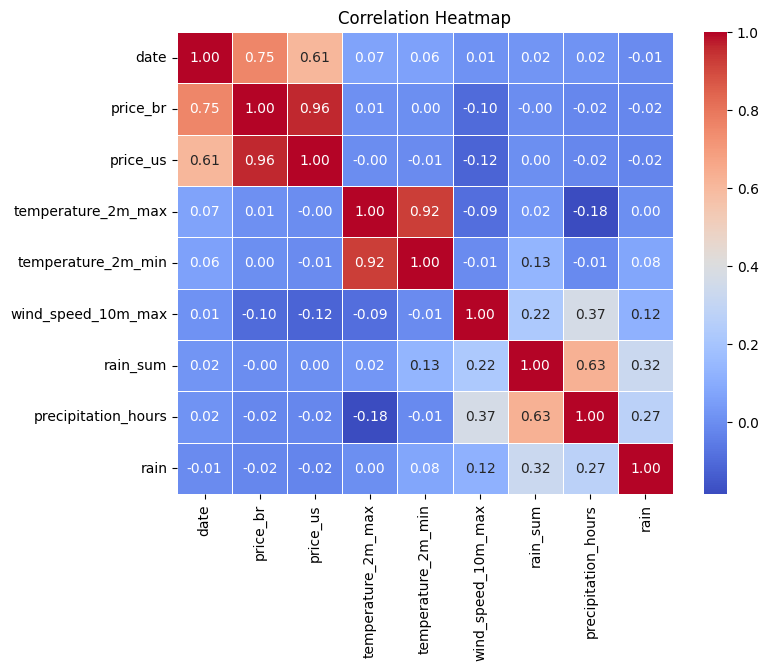

In [21]:
import seaborn as sns
matrix = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

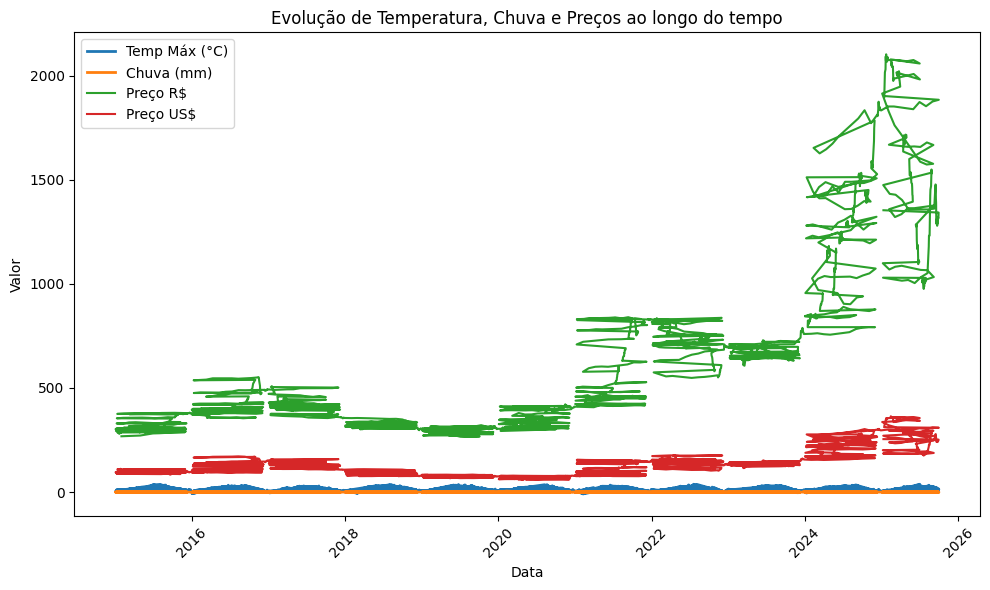

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plota cada coluna em função da data
ax.plot(df['date'], df['temperature_2m_max'], label='Temp Máx (°C)', linewidth=2)
ax.plot(df['date'], df['rain'], label='Chuva (mm)', linewidth=2)
ax.plot(df['date'], df['price_br'], label='Preço R$')
ax.plot(df['date'], df['price_us'], label='Preço US$')

ax.set_title("Evolução de Temperatura, Chuva e Preços ao longo do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Valor")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Treinando o modelo

In [23]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['year'] = df['date'].dt.year

X = df[['temperature_2m_max', 'temperature_2m_min', 'wind_speed_10m_max', 'rain_sum', 'rain', 'precipitation_hours', 'month', 'day_of_week', 'year']]
y = df[['price_br', 'price_us']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

print("--- Treinando o Modelo de Regressão Linear Múltipla ---")
modelo_rl = LinearRegression()
modelo_rl.fit(X_train_normalized, y_train)

y_pred_rl = modelo_rl.predict(X_test_normalized)
mse_rl = mean_squared_error(y_test, y_pred_rl)
r2_rl = r2_score(y_test, y_pred_rl)

print(f"MSE: {mse_rl:.4f}")
print(f"R²: {r2_rl:.4f}")
print("-" * 40)

--- Treinando o Modelo de Regressão Linear Múltipla ---
MSE: 30527.6000
R²: 0.4527
----------------------------------------


In [25]:
print("--- Modelo 2: Árvore de Decisão ---")
modelo_ad = DecisionTreeRegressor(random_state=42)
modelo_ad.fit(X_train_normalized, y_train)
y_pred_ad = modelo_ad.predict(X_test_normalized)

mse_ad = mean_squared_error(y_test, y_pred_ad)
r2_ad = r2_score(y_test, y_pred_ad)

print(f"MSE: {mse_ad:.4f}")
print(f"R²: {r2_ad:.4f}")
print("-" * 40)

--- Modelo 2: Árvore de Decisão ---
MSE: 12919.5387
R²: 0.8104
----------------------------------------


In [26]:
print("--- Modelo 3: Random Forest ---")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_normalized, y_train)
y_pred_rf = modelo_rf.predict(X_test_normalized)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")
print("-" * 40)

--- Modelo 3: Random Forest ---
MSE: 6486.5690
R²: 0.9021
----------------------------------------


In [27]:
modelo_rf = RandomForestRegressor(random_state=42)

# 'n_estimators': número de árvores na floresta
# 'max_depth': profundidade máxima de cada árvore
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None]    
}

# 'scoring': a métrica que será usada para avaliar os modelos (o R² é uma boa opção)
grid_search = GridSearchCV(estimator=modelo_rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# Isso pode levar alguns minutos, dependendo da sua máquina
grid_search.fit(X_train_normalized, y_train)

# 5. Imprima os melhores parâmetros e a melhor pontuação
print("Melhores parâmetros encontrados: ", grid_search.best_params_)
print("Melhor pontuação R²: ", grid_search.best_score_)

# 6. Use o melhor modelo para fazer previsões e avaliar
best_modelo_rf = grid_search.best_estimator_
y_pred_tuned = best_modelo_rf.predict(X_test_normalized)

# Avaliação final do modelo otimizado
r2_tuned = r2_score(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
print(f"R² do modelo otimizado no teste: {r2_tuned:.4f}")
print(f"MSE do modelo otimizado no teste: {mse_tuned:.4f}")

Melhores parâmetros encontrados:  {'max_depth': 10, 'n_estimators': 200}
Melhor pontuação R²:  0.9073198788783312
R² do modelo otimizado no teste: 0.9033
MSE do modelo otimizado no teste: 6362.7132


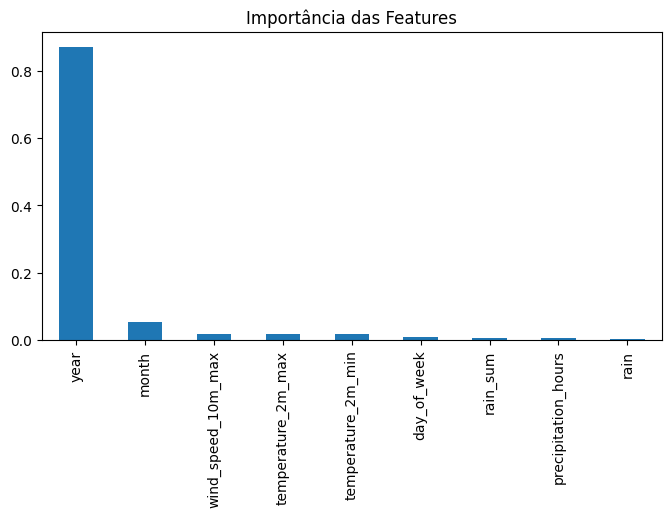

In [28]:
importances = pd.Series(best_modelo_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(8,4), title="Importância das Features")
plt.show()

In [29]:
print(y_pred_tuned)

[[637.26120877 121.04840076]
 [304.3152077   97.54812469]
 [289.08162378  73.10196419]
 ...
 [700.28586402 133.73883549]
 [670.93547489 132.66854678]
 [328.51260106  87.60635927]]


# Salvando o modelo para aplicação

In [30]:
import joblib
from dotenv import load_dotenv
import os
load_dotenv()

model_path = os.getenv("MODEL_PATH")

# Suponha que o modelo já foi treinado
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Salvar o modelo no disco
joblib.dump(model, f"{model_path}/modelo_random_forest.pkl")


['C:/Users/Overthrive/Documents/faculdade_ml/tech_challenge/MLE-Posgraduate-projects/tech_challenge3/project/source/model/modelo_random_forest.pkl']